# Fig 1 — Cohort overview, classifiers, and location survival

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('discovery_archetype', 'fig1')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
from dlbcl.dlbcl_io import (
    DISCOVERY_PATIENTS,
    consolidate_embedded_case_classifications,
    ensure_discovery_archetypes,
    rel_path,
    log_wrote,
    log_saved,
)
print(f"AnnData: {rel_path(_paths.adata_path, REPO_ROOT)}")
print(f"Figures: {rel_path(FIG_DIR, REPO_ROOT)}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

from dlbcl.integration_figures import build_integration_metadata
from dlbcl.location_pie_patchwork import (
    GENOMIC_STACKED_BAR_COLS,
    LYMPHGEN_DLBCLASS_COLS,
    format_pie_patchwork_supplementary_table,
    prepare_pie_patchwork_table,
    plot_location_pie_patchwork,
    plot_location_stacked_bar_patchwork,
)

FIG_1D = FIG_DIR / "fig1D_classifier_pie_patchwork.svg"
FIG_1D_LEGEND = FIG_DIR / "fig1D_classifier_pie_patchwork_legend.svg"
FIG_1D_LEGEND_PNG = FIG_DIR / "fig1D_classifier_pie_patchwork_legend.png"
FIG_1D_GENOMIC_STACKED = FIG_DIR / "fig1D_location_genomic_stacked_bars.svg"
FIG_1D_GENOMIC_STACKED_PNG = FIG_DIR / "fig1D_location_genomic_stacked_bars.png"
FIG_1D_LYMPHGEN_DLBCLASS_STACKED = FIG_DIR / "fig1D_location_lymphgen_dlbclass_stacked_bars.svg"
FIG_1D_LYMPHGEN_DLBCLASS_STACKED_PNG = FIG_DIR / "fig1D_location_lymphgen_dlbclass_stacked_bars.png"

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

from dlbcl.discovery_km import (
    ENDPOINTS,
    KM_HORIZON_YEARS,
    plot_km_by_archetype,
    plot_km_by_location,
)


AnnData: DLBCL_location_2026.h5ad
Figures: figures/fig1


## Fig 1 — panels in this notebook
Reproduces:
- **Fig 1D** — location × classifier composition (pie grid)
- **Fig 1E / 1F** — Kaplan–Meier survival by anatomical location

Related panels in other notebooks: **Fig S2A** (cohort modality matrix), **Fig S1A** (genomic oncoprint; requires R).

**Data:** `data/DLBCL_location_2026.h5ad` only (see `README.md`).


## Load data

In [2]:
adata = sc.read_h5ad(ADATA_PATH)

adata_subset = adata[adata.obs["patient_id"].isin(PATIENT_SUBSET)].copy()

from dlbcl.dlbcl_io import load_discovery_metadata

meta = load_discovery_metadata(adata_subset, PATIENT_SUBSET)

# Human genes only (drop EBV EBER2 spike-in)
expr = adata_subset.uns["gene_expression"]
adata_subset.uns["gene_expression"] = expr.drop(index="EBER2", errors="ignore")

del adata
gc.collect()

print(f"Patients: {adata_subset.n_obs:,} cells | cohort n={meta['patient_id'].nunique()}")


Patients: 1,266,162 cells | cohort n=64


In [3]:
meta.head()



,patient_id,Location,lymphomap,Lymphoma_Ecotype,KotlovSig,Ciav_Cluster,COO_NanoString,Lymphgen_aug2024,Lymphoma_Ecotype_original_update,New_Ecotype_update,...,IPI/IELSG,Treatment_Line_1_Response2,COO_NanoString_clinical,tMYC_clinical,tBCL2_clinical,tBCL6_clinical,EBER_clinical,Curative_intent,Treatment category,consolidation
0,T1,PCNS,LN,unknown,Inflammatory,Hot,ABC,MCD,unknown,LE6,...,3,PD,ABC,NEG,UNK,UNK,NEG,1,HD-MTX-based polychemotherapy,unknown
1,T10,PCNS,FMAC,LE2,Depleted,Hot,ABC,Other,LE2,LE2,...,unknown,unknown,ABC,NEG,UNK,UNK,NEG,0,No curative intent,unknown
2,T12,PCNS,LN,LE6,GC-like,Hot,GCB,Other,LE6,LE6,...,2,PD,GCB,NEG,UNK,UNK,NEG,1,HD-MTX-based polychemotherapy,unknown
3,T13,PCNS,FMAC,unknown,Inflammatory,Hot,Intermediate,BN2,unknown,LE2,...,0,CR,Intermediate,NEG,UNK,UNK,NEG,1,HD-MTX-based polychemotherapy,ASCT
4,T14,PCNS,FMAC,unknown,Depleted,Hot,ABC,BN2/MCD,unknown,LE2,...,2,unknown,ABC,NEG,UNK,UNK,NEG,0,No curative intent,unknown


In [4]:
meta.columns.tolist()

['patient_id',
 'Location',
 'lymphomap',
 'Lymphoma_Ecotype',
 'KotlovSig',
 'Ciav_Cluster',
 'COO_NanoString',
 'Lymphgen_aug2024',
 'Lymphoma_Ecotype_original_update',
 'New_Ecotype_update',
 'KotlovSig_update',
 'Ciav_Cluster_update',
 'COO_NanoString_update',
 'DLBclass',
 'LymphGen_update',
 'abundance_cluster',
 'abundance_cluster_30_label',
 'abundance_cluster_30',
 'HLAABC',
 'HLADR',
 'HLA_class_state',
 'HLA_class_state_short',
 'HLAABC_path',
 'HLADR_path',
 'Age',
 'COO',
 'HGL',
 'tMYC',
 'tBCL2',
 'tBCL6',
 'CD10_IHC',
 'MUM1_IHC',
 'BCL6_IHC ',
 'BCL2_IHC',
 'MYC_IHC',
 'EBER',
 'COO_Hans',
 'CD10_IHC.1',
 'BCL6_IHC',
 'MUM1_IHC.1',
 'MYC_Expr',
 'MYC_IHC_TRUE',
 'BCL2_IHC.1',
 'MYC_Rear',
 'BCL2_Rear',
 'BCL6_Rear',
 'HGBCL',
 'Double_Expr',
 'EBER.1',
 'TP53_Mutation',
 'Mut_Burden',
 'OS_status_JV',
 'OS_specific_status_JV',
 'OS_status_cats_JV',
 'Relapse_status',
 'OS_time_JV',
 'pfs_time',
 'pfs_status',
 'Location_clinical',
 'Location_group',
 'Age_clinical',
 '

In [5]:
adata_subset

AnnData object with n_obs × n_vars = 1266162 × 40
    obs: 'Area', 'Perimeter', 'Convex_Area', 'Solidity', 'BoundingBox_Area', 'Extent', 'Orientation', 'Eccentricity', 'Equivalent_Diameter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Major_Minor_Axis_Ratio', 'Circularity', 'Form_Factor', 'Euler_Number', 'Nucleus_Area', 'Nucleus_Eccentricity', 'NC_Area_Ratio', 'Centroid_Deviation', 'ExclusionMembrane_Area', 'Mean_DNA1_Intensity', 'Integrated_DNA1_Intensity', 'Mean_DNA2_Intensity', 'Integrated_DNA2_Intensity', 'Mean_HistoneH3_Intensity', 'Integrated_HistoneH3_Intensity', 'QC_no_nucleus', 'fov', 'patient_id', 'summed_intensity', 'total_intensity', 'QC_low_intensity_filter', 'QC_filter_low_quality_region', 'filtering_status', 'QC_fraction_filtered', 'QC_dr_based_filter', 'QC_final_keep', 'subclass', 'phenotype_16_bm', 'phenotype_16_clean', 'phenotype_30_clean', 'phenotype_30_bm'
    uns: 'X_source', 'case_classifications', 'case_clinical', 'case_path', 'celltype_colormap_16', 'celltype_col

## Fig 1D — Location × classifier composition
Reproduces **Fig 1D**: patient-level pie grid with **rows = classifiers** and **columns = tumor location** (10×4 transposed layout).
using the same AnnData bundle as the other Fig 1 notebooks:
- `data/DLBCL_location_2026.h5ad` (`uns['case_classifications']`)
- Immune archetype labels embedded in `adata.uns`
- Genomic classifier labels embedded in `uns['case_classifications']`
Related panels: **Fig S2A**, **Fig S2B**.
| Output | Path |
|--------|------|
| Fig 1D classifier grid | `figures/fig1/fig1D_classifier_pie_patchwork.svg` |
| Legend | `figures/fig1/fig1D_classifier_pie_patchwork_legend.svg` |

## Load discovery cohort

In [6]:
adata = sc.read_h5ad(_paths.adata_path)
mask = adata.obs["patient_id"].isin(DISCOVERY_PATIENTS) & (
    adata.obs["filtering_status"] == "Unfiltered"
)
adata = adata[mask].copy()
gc.collect()

arch_df = ensure_discovery_archetypes(adata, _paths)
adata = consolidate_embedded_case_classifications(adata, _paths, repo_root=REPO_ROOT)

meta = build_integration_metadata(
    adata,
    arch_df,
    patient_subset=DISCOVERY_PATIENTS,
)
not_tested = sorted(meta.index[~meta["genomic_tested"]]) if "genomic_tested" in meta.columns else []
print(f"Patients in pie grid: n={len(meta)}")
if not_tested:
    print(f"WES failed / no source variants (included; genomic_tested=False): {not_tested}")


Patients in pie grid: n=64
WES failed / no source variants (included; genomic_tested=False): ['T29', 'T41', 'T48']


## Fig 1D — pie patchwork grid

Classifiers: ['Spatial Protein', 'Cell of Origin', 'Ciavarella 2018\nCluster', 'Steen 2021\nLymphoma_Ecotype', 'Kotlov 2021\nLME', 'Li 2025\nLymphoMAP', 'Wright 2020\nLymphgen', 'Chapuy 2025\nDLBclass']
Saved: data/supplementary/fig1/fig1D_pie_patients.csv


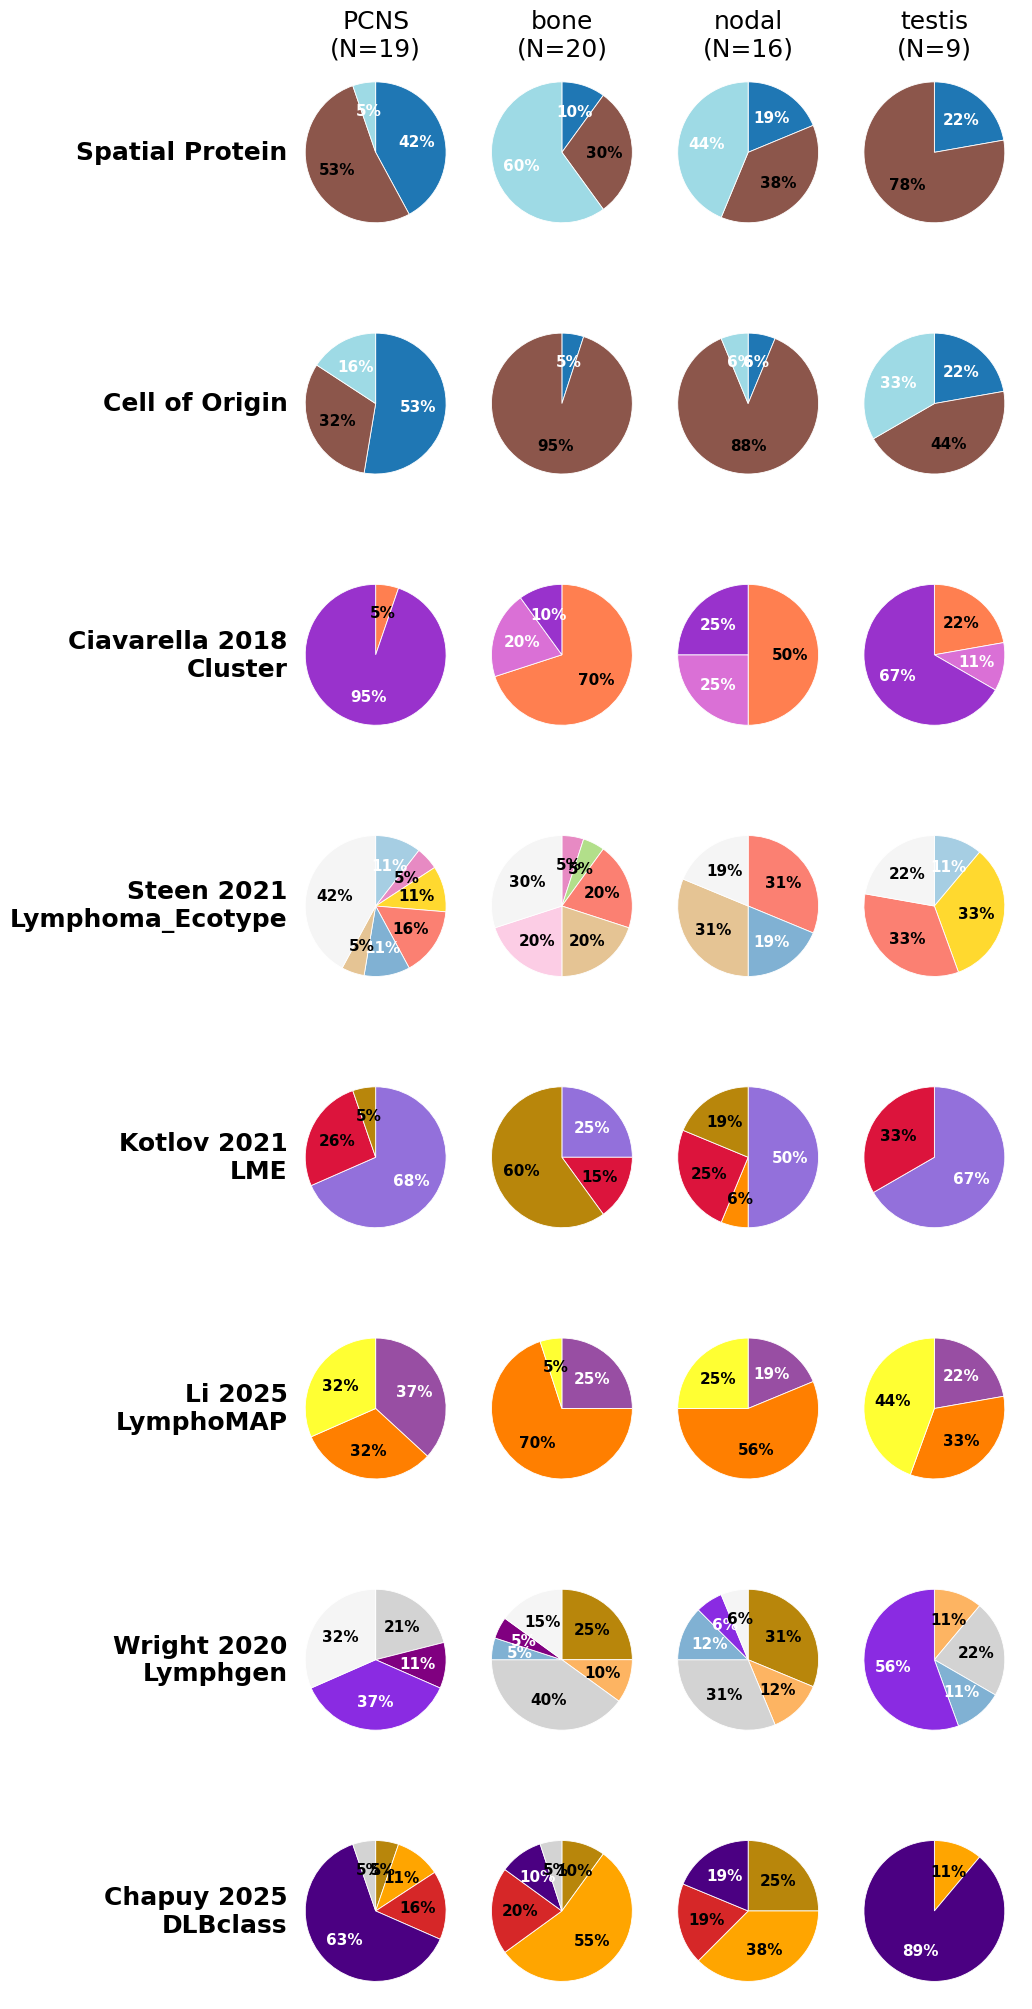

Wrote figures/fig1/fig1D_classifier_pie_patchwork.svg
Wrote figures/fig1/fig1D_classifier_pie_patchwork_legend.svg
Wrote figures/fig1/fig1D_classifier_pie_patchwork_legend.png


In [7]:
pie_df, molecular_cols, label_by_col = prepare_pie_patchwork_table(meta)
print("Classifiers:", [label_by_col[c] for c in molecular_cols])
log_saved(
    write_supplementary_table(
        format_pie_patchwork_supplementary_table(pie_df),
        REPO_ROOT,
        "fig1D_pie_patients",
    ),
    REPO_ROOT,
)

plot_location_pie_patchwork(
    pie_df,
    molecular_cols,
    label_by_col,
    out_svg=FIG_1D,
    legend_svg=FIG_1D_LEGEND,
    legend_png=FIG_1D_LEGEND_PNG,
    layout="classifiers_rows",
    legend_height_scale=3.5,
    show=True,
)
log_wrote(FIG_1D, REPO_ROOT)
log_wrote(FIG_1D_LEGEND, REPO_ROOT)
log_wrote(FIG_1D_LEGEND_PNG, REPO_ROOT)


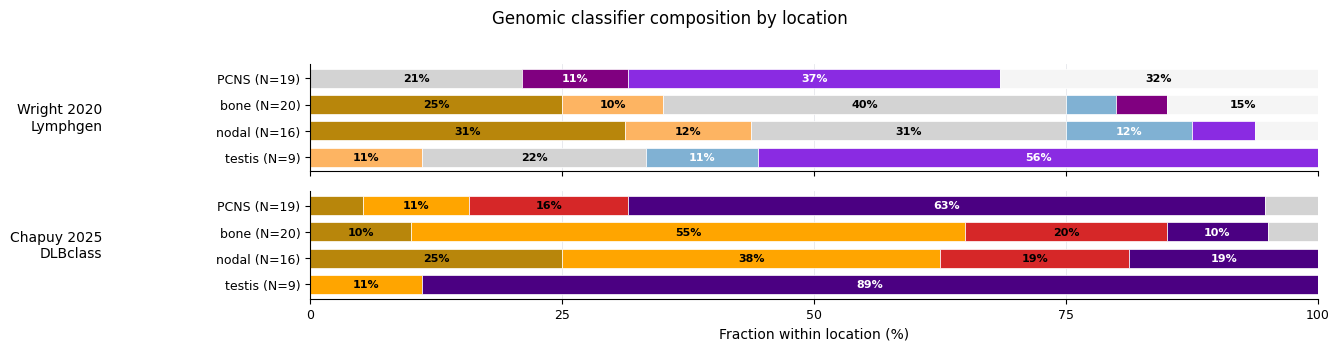

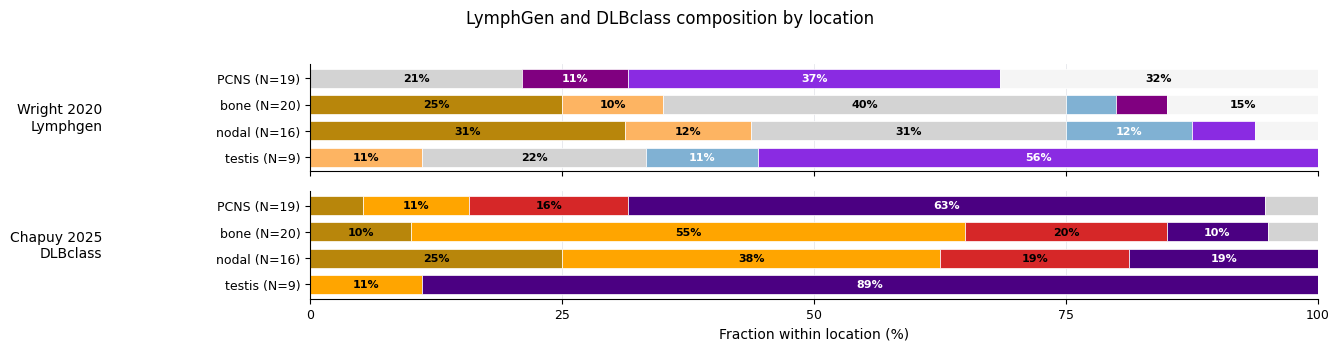

Wrote figures/fig1/fig1D_location_genomic_stacked_bars.svg
Wrote figures/fig1/fig1D_location_genomic_stacked_bars.png
Wrote figures/fig1/fig1D_location_lymphgen_dlbclass_stacked_bars.svg
Wrote figures/fig1/fig1D_location_lymphgen_dlbclass_stacked_bars.png


In [8]:
# Fig 1D option — row-normalized stacked bars for genomic classifiers
genomic_stacked_cols = [col for col in GENOMIC_STACKED_BAR_COLS if col in molecular_cols]
lymphgen_dlbclass_cols = [col for col in LYMPHGEN_DLBCLASS_COLS if col in molecular_cols]

plot_location_stacked_bar_patchwork(
    pie_df,
    genomic_stacked_cols,
    label_by_col,
    out_svg=FIG_1D_GENOMIC_STACKED,
    out_png=FIG_1D_GENOMIC_STACKED_PNG,
    title="Genomic classifier composition by location",
    show=True,
)
plot_location_stacked_bar_patchwork(
    pie_df,
    lymphgen_dlbclass_cols,
    label_by_col,
    out_svg=FIG_1D_LYMPHGEN_DLBCLASS_STACKED,
    out_png=FIG_1D_LYMPHGEN_DLBCLASS_STACKED_PNG,
    title="LymphGen and DLBclass composition by location",
    show=True,
)
for path in [
    FIG_1D_GENOMIC_STACKED,
    FIG_1D_GENOMIC_STACKED_PNG,
    FIG_1D_LYMPHGEN_DLBCLASS_STACKED,
    FIG_1D_LYMPHGEN_DLBCLASS_STACKED_PNG,
]:
    log_wrote(path, REPO_ROOT)


## Fig 1E / 1F — KM by location (+ Supp DSS)

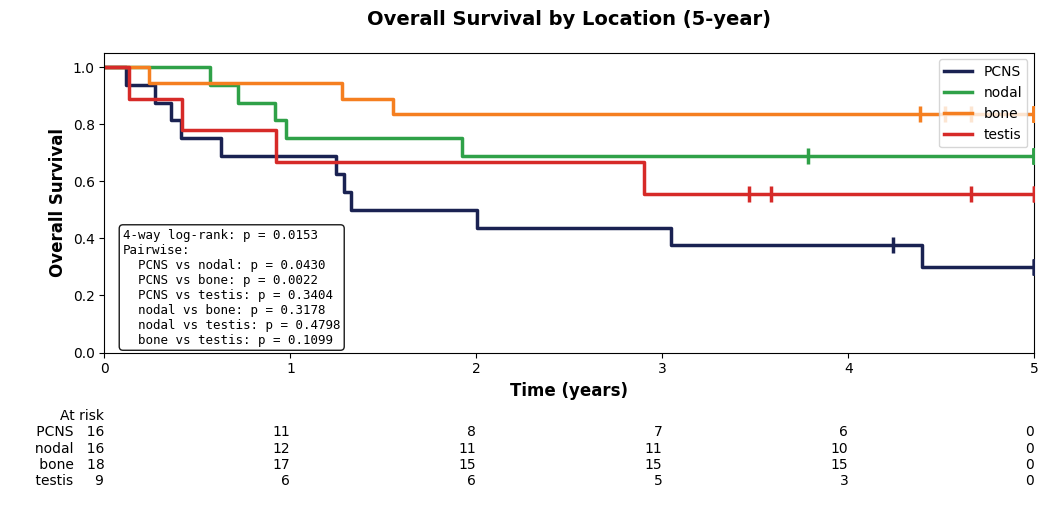

Wrote figures/fig1/fig1E_km_os_location.svg


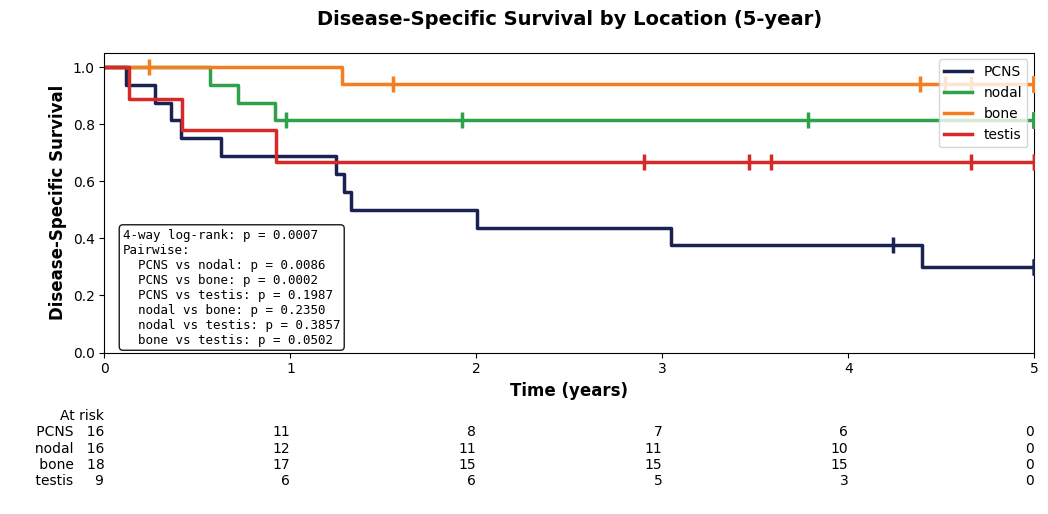

Wrote figures/fig1/figS_supp_km_dss_location.svg


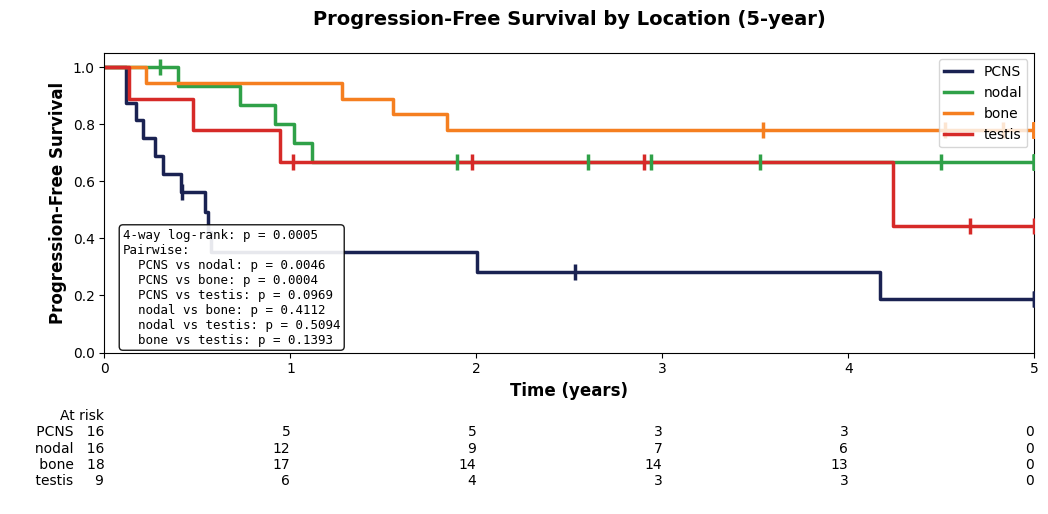

Wrote figures/fig1/fig1F_km_pfs_location.svg


In [9]:
loc_os = plot_km_by_location(
    surv,
    time_col=ENDPOINTS["OS"]["time"],
    event_col=ENDPOINTS["OS"]["event"],
    title=f"Overall Survival by Location ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Overall Survival",
    out_path=FIG_DIR / "fig1E_km_os_location.svg",
)
loc_dss = plot_km_by_location(
    surv,
    time_col=ENDPOINTS["DSS"]["time"],
    event_col=ENDPOINTS["DSS"]["event"],
    title=f"Disease-Specific Survival by Location ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Disease-Specific Survival",
    out_path=FIG_DIR / "figS_supp_km_dss_location.svg",
)
loc_pfs = plot_km_by_location(
    surv,
    time_col=ENDPOINTS["PFS"]["time"],
    event_col=ENDPOINTS["PFS"]["event"],
    title=f"Progression-Free Survival by Location ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Progression-Free Survival",
    out_path=FIG_DIR / "fig1F_km_pfs_location.svg",
)
loc_os.to_csv(OUTDIR / "fig1E_km_os_location_summary.csv", index=False)
loc_dss.to_csv(OUTDIR / "figS_supp_km_dss_location_summary.csv", index=False)
loc_pfs.to_csv(OUTDIR / "fig1F_km_pfs_location_summary.csv", index=False)
